In [1]:
import tensorflow as tf
from tensorflow.keras.layers import Input, ConvLSTM2D, GlobalAveragePooling2D, Conv3D, Flatten, Dense, Dropout, LayerNormalization, GlobalAveragePooling3D, Concatenate, TimeDistributed, MaxPooling3D, AveragePooling3D, GlobalMaxPooling3D, LSTM, Lambda
from tensorflow.keras.models import Model
import numpy as np
import pickle as pkl

2025-03-11 16:51:20.858613: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-11 16:51:20.938722: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-11 16:51:20.938765: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-11 16:51:20.938807: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-11 16:51:20.948761: I tensorflow/core/platform/cpu_feature_g

In [2]:
devices = tf.config.list_physical_devices()
print(devices)

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
tf.config.set_visible_devices([], 'GPU')

In [4]:
# importing data
def returning_pkl_file_data(path : str):
    with open(path, 'rb') as f:
        temp = pkl.load(f)
    return temp

mci_func = returning_pkl_file_data(r"feature_extraction/mci_features_52_197_116.pkl")
mci_struct = returning_pkl_file_data(r'feature_extraction/MCI_struct_cat_52_169_205_169.pkl')
cn_func = returning_pkl_file_data(r'feature_extraction/cn_features_42_197_116.pkl')
cn_struct = returning_pkl_file_data(r'feature_extraction/CN_struct_cat_42_169_205_169.pkl')

In [5]:
func_data = np.concatenate((mci_func, cn_func), axis=0, dtype=np.float32)
func_data.shape

(94, 197, 116)

In [6]:
struct_data = np.concatenate((mci_struct, cn_struct), axis=0, dtype=np.float32)
struct_data.shape

(94, 169, 205, 169)

In [7]:
all_labels = np.concatenate((np.zeros((len(mci_struct),)), np.ones((len(cn_struct),))))
all_labels.shape

(94,)

In [8]:
# func_data = np.expand_dims(func_data, axis=len(func_data.shape))
struct_data = np.expand_dims(struct_data, axis=len(struct_data.shape))

struct_data.shape, func_data.shape

((94, 169, 205, 169, 1), (94, 197, 116))

In [17]:
from sklearn.model_selection import train_test_split

func_train, func_test, struct_train, struct_test, y_train, y_test = train_test_split(
    func_data, struct_data, all_labels, test_size=0.2, random_state=40
)

func_train.shape, func_test.shape, struct_train.shape, struct_test.shape, y_train.shape, y_test.shape

((75, 197, 116),
 (19, 197, 116),
 (75, 169, 205, 169, 1),
 (19, 169, 205, 169, 1),
 (75,),
 (19,))

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import math

class PositionalEncoding(layers.Layer):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        self.d_model = d_model
        
        position = tf.range(max_len, dtype=tf.float32)[:, tf.newaxis]
        div_term = tf.exp(tf.range(0, d_model, 2, dtype=tf.float32) * (-math.log(10000.0) / d_model))
        
        pe = tf.zeros((max_len, d_model))
        pe = tf.Variable(pe, trainable=False)
        pe[:, 0::2].assign(tf.sin(position * div_term))
        pe[:, 1::2].assign(tf.cos(position * div_term))
        self.pe = pe[tf.newaxis, ...]

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.pe[:, :seq_len, :]

class TransformerEncoderBlock(layers.Layer):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)
        self.ffn = tf.keras.Sequential([
            layers.Dense(ff_dim, activation="gelu"),
            layers.Dense(d_model)
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout)
        self.dropout2 = layers.Dropout(dropout)

    def call(self, inputs, training=False):
        attn_output = self.attn(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

def build_transformer_model(input_shape=(func_data.shape[1:]), 
                            embedding_dim=128,
                            num_heads=8,
                            ff_dim=512,
                            num_layers=4,
                            dropout=0.1,
                            use_mean_pooling=True):
    # Input layer
    fmri_input = layers.Input(shape=input_shape, name="fmri_input", dtype=tf.float32)
    
    # Embedding layer
    x = layers.Dense(embedding_dim, activation="gelu")(fmri_input)
    
    # Positional encoding
    x = PositionalEncoding(embedding_dim)(x)
    
    # Transformer encoder
    for _ in range(num_layers):
        x = TransformerEncoderBlock(embedding_dim, num_heads, ff_dim, dropout)(x)
    
    # Pooling
    if use_mean_pooling:
        pooled_output = layers.GlobalAveragePooling1D()(x)
    else:  # Use first token (BERT-style)
        pooled_output = x[:, 0, :]
    
    # Classification
    output = (pooled_output)
    
    return Model(inputs=fmri_input, outputs=output, name="MeanTransformer" if use_mean_pooling else "Transformer")

# Example usage
def build_combined_model(fmri_shape=(func_data.shape[1:]),
                         smri_shape=(struct_data.shape[1:]),
                         transformer_params=None):
    # Default transformer parameters
    if transformer_params is None:
        transformer_params = {
            'embedding_dim': 128,
            'num_heads': 4,
            'ff_dim': 512,
            'num_layers': 4,
            'dropout': 0.3,
            'use_mean_pooling': True
        }
    
    # Build models
    fmri_model = build_transformer_model(input_shape=fmri_shape, **transformer_params)
    
    # sMRI model (3D CNN)
    smri_input = layers.Input(shape=smri_shape, name="smri_input", dtype=tf.float32)
    y = layers.Conv3D(32, 3, activation="gelu", padding="valid")(smri_input)
    y = layers.MaxPooling3D(2)(y)
    y = layers.Conv3D(64, 3, activation="gelu", padding="valid")(y)
    y = layers.MaxPooling3D(2)(y)
    y = layers.Conv3D(128, 3, activation="gelu", padding="valid")(y)
    y = layers.MaxPooling3D(2)(y)
    y = layers.Flatten()(y)
    y = layers.Dense(128, activation="gelu")(y)
    smri_model = Model(inputs=smri_input, outputs=y, name="sMRI_Model")
    
        # Combine both branches
    attn_scores = tf.keras.layers.Attention()([smri_model.output, fmri_model.output])  # Concatenate outputs
    combined = tf.keras.layers.Concatenate()([attn_scores, smri_model.output, fmri_model.output])
    z = Dense(64, activation='gelu')(combined)  # Fully connected layer
    z = Dropout(0.5)(z)  # Dropout for regularization
    output = Dense(1, activation='sigmoid')(z)  # Binary classification output

    # Create the model
    return Model(inputs=[fmri_model.input, smri_input], outputs=output)
    
tf.keras.mixed_precision.set_global_policy('float32')
# Build and compile model
tf.keras.utils.set_random_seed(42)
model = build_combined_model()


In [11]:

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 smri_input (InputLayer)     [(None, 169, 205, 169, 1)]   0         []                            
                                                                                                  
 conv3d (Conv3D)             (None, 167, 203, 167, 32)    896       ['smri_input[0][0]']          
                                                                                                  
 fmri_input (InputLayer)     [(None, 197, 116)]           0         []                            
                                                                                                  
 max_pooling3d (MaxPooling3  (None, 83, 101, 83, 32)      0         ['conv3d[0][0]']              
 D)                                                                                           

In [23]:
# func_data = np.random.rand(100, 4, 4, 4, 5).astype(np.float32)
struct_data = np.random.rand(100, 10, 10, 10, 1).astype(np.float32)
all_labels = np.random.randint(0, 2, size=(100,))
struct_data.shape, all_labels.shape#, func_data.shape 

((100, 10, 10, 10, 1), (100,))

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
struct_train, struct_test, y_train, y_test = train_test_split(struct_data, all_labels, test_size=0.2, random_state=42)
struct_train.shape, struct_test.shape, y_train.shape, y_test.shape

((80, 10, 10, 10, 1), (20, 10, 10, 10, 1), (80,), (20,))

In [12]:
history = model.fit(
    {"fmri_input" : func_train, "smri_input": struct_train},  # Dictionary format for inputs
    y_train,  # Output labels
    batch_size=8,
    epochs=20,
    validation_data=(
        {"fmri_input" : func_test, "smri_input": struct_test},
        y_test
    ),
    verbose=1
)

Epoch 1/20


2025-03-11 16:54:06.123304: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x769cac00b890 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2025-03-11 16:54:06.123523: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): Host, Default Version
2025-03-11 16:54:06.277605: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-03-11 16:54:07.044644: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2025-03-11 16:54:07.055676: E ./tensorflow/compiler/xla/stream_executor/stream_executor_internal.h:124] SetPriority unimplemented for this stream.
2025-03-11 16:54:07.668715: E ./tensorflow/compiler/xla/stream_executor/stream_executor_internal.h:124] SetPriority unimplemented for this stream.
2025-03-11 16:54:08.29629

 8/10 [=======================>......] - ETA: 18s - loss: 0.7896 - accuracy: 0.4219

2025-03-11 16:55:22.025687: E ./tensorflow/compiler/xla/stream_executor/stream_executor_internal.h:124] SetPriority unimplemented for this stream.


10/10 [==============================] - 130s 10s/step - loss: 0.7922 - accuracy: 0.4000 - val_loss: 0.6672 - val_accuracy: 0.6316
Epoch 2/20
10/10 [==============================] - 91s 9s/step - loss: 0.8087 - accuracy: 0.4800 - val_loss: 0.6429 - val_accuracy: 0.6316
Epoch 3/20
10/10 [==============================] - 94s 10s/step - loss: 0.7055 - accuracy: 0.5200 - val_loss: 0.6452 - val_accuracy: 0.6316
Epoch 4/20
10/10 [==============================] - 90s 9s/step - loss: 0.6513 - accuracy: 0.6400 - val_loss: 0.5937 - val_accuracy: 0.6316
Epoch 5/20
10/10 [==============================] - 90s 9s/step - loss: 0.6271 - accuracy: 0.6133 - val_loss: 0.6043 - val_accuracy: 0.6316
Epoch 6/20
10/10 [==============================] - 96s 10s/step - loss: 0.6163 - accuracy: 0.6533 - val_loss: 0.6074 - val_accuracy: 0.6842
Epoch 7/20
10/10 [==============================] - 96s 10s/step - loss: 0.5917 - accuracy: 0.6800 - val_loss: 0.6223 - val_accuracy: 0.7368
Epoch 8/20
10/10 [========

2025-03-11 17:09:58.138181: E ./tensorflow/compiler/xla/stream_executor/stream_executor_internal.h:124] SetPriority unimplemented for this stream.


10/10 [==============================] - 99s 10s/step - loss: 0.4086 - accuracy: 0.8133 - val_loss: 0.8000 - val_accuracy: 0.6842
Epoch 12/20
10/10 [==============================] - 100s 10s/step - loss: 0.3566 - accuracy: 0.8400 - val_loss: 0.7825 - val_accuracy: 0.5263
Epoch 13/20
10/10 [==============================] - 100s 10s/step - loss: 0.3092 - accuracy: 0.8533 - val_loss: 0.8370 - val_accuracy: 0.6842
Epoch 14/20
10/10 [==============================] - 101s 10s/step - loss: 0.2289 - accuracy: 0.8933 - val_loss: 0.9387 - val_accuracy: 0.6842
Epoch 15/20
10/10 [==============================] - 105s 11s/step - loss: 0.3167 - accuracy: 0.8533 - val_loss: 0.8130 - val_accuracy: 0.6316
Epoch 16/20
10/10 [==============================] - 71s 7s/step - loss: 0.1895 - accuracy: 0.9067 - val_loss: 1.0035 - val_accuracy: 0.6842
Epoch 17/20
10/10 [==============================] - 62s 6s/step - loss: 0.2075 - accuracy: 0.9333 - val_loss: 1.0022 - val_accuracy: 0.5263
Epoch 18/20
10/1

In [18]:
loss, accuracy = model.evaluate({
    "fmri_input":func_test, "smri_input":struct_test
    },
    y_test
)
print(f"Validation loss: {loss}")
print(f"Validation accuracy: {accuracy}")

1/1 [==============================] - 4s 4s/step - loss: 0.3136 - accuracy: 0.8421
Validation loss: 0.3135627806186676
Validation accuracy: 0.8421052694320679


In [19]:
model.save("feature_extraction/mci_cn_transformer_84.h5")

/home/tripti/miniconda3/lib/python3.9/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [20]:
y_preds = model.predict({
    "fmri_input" : func_test,
    "smri_input" : struct_test
})
y_preds

1/1 [==============================] - 5s 5s/step


array([[2.8586958e-04],
       [9.9012035e-01],
       [1.9757222e-01],
       [8.9884394e-01],
       [1.6475923e-02],
       [5.6649432e-02],
       [2.9998823e-04],
       [1.9437990e-04],
       [3.2739690e-01],
       [9.2827767e-02],
       [5.3540599e-01],
       [3.5635015e-04],
       [8.5018003e-01],
       [8.5377789e-01],
       [9.6682000e-01],
       [9.8913085e-01],
       [2.2161317e-01],
       [2.6067984e-04],
       [4.4130197e-01]], dtype=float32)

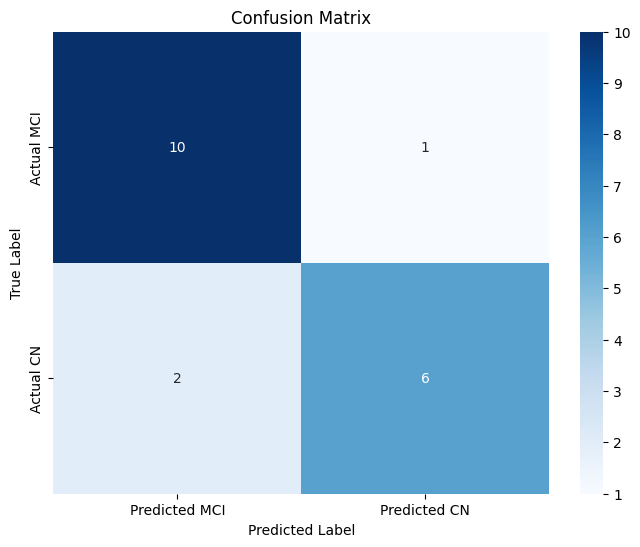

In [21]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming y_true contains the true labels (ground truth)
# y_true should be a numpy array of shape (n_samples,) with values 0 or 1

# Step 1: Convert probabilities to binary predictions
threshold = 0.5
y_preds_binary = (y_preds > threshold).astype(int)

# Step 2: Compute the confusion matrix
cm = confusion_matrix(y_test, y_preds_binary)

# Step 3: Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted MCI', 'Predicted CN'], 
            yticklabels=['Actual MCI', 'Actual CN'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [22]:
from sklearn.metrics import classification_report

# Step 2: Generate the classification report
report = classification_report(y_test, y_preds_binary, target_names=['MCI', 'CN'])

# Step 3: Print the report
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

         MCI       0.83      0.91      0.87        11
          CN       0.86      0.75      0.80         8

    accuracy                           0.84        19
   macro avg       0.85      0.83      0.83        19
weighted avg       0.84      0.84      0.84        19



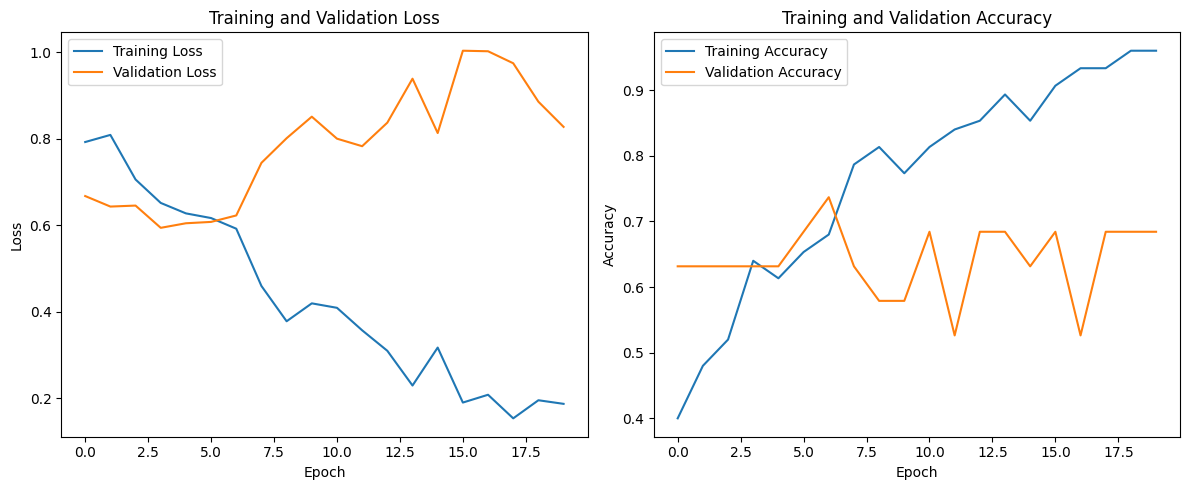

In [23]:
import matplotlib.pyplot as plt

# Plot training and validation loss
plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()